# Hopper D4RL Diagnostics — Reference Baseline for v0.2.5.X Metrics

Extract v0.2.5.X custom diagnostics on SOPE's reference D4RL Hopper implementation to establish ground-truth values for comparison against our robomimic Lift implementation.

**Diagnostics:**
1. Pairwise cosine similarity of scorer gradients (cf. v0.2.5.6, .8, .9)
2. |grad| / |action| ratio (cf. v0.2.5.3)
3. Gradient direction test — can GD converge random→real action? (cf. v0.2.5.4)
4. Per-dimension trajectory MSE (cf. v0.2.5.2)
5. Action NLL under target policy (cf. v0.2.5.7)
6. Trajectory plots — real vs synthetic (cf. all v0.2.5.X)

In [1]:
import sys, os
os.environ["D4RL_SUPPRESS_IMPORT_ERROR"] = "1"

sys.path.insert(0, os.path.join(os.getcwd(), "../../third_party/sope"))

import torch
import numpy as np
from scipy import stats as scipy_stats
import gym
import d4rl
%matplotlib inline
import matplotlib.pyplot as plt
from itertools import combinations

from opelab.core.policy import D4RLSACPolicy, D4RLPolicy
from opelab.core.baselines.diffusion.diffusion import gradlog, GaussianDiffusion
from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.helpers import apply_conditioning

SOPE_ROOT = os.path.join(os.getcwd(), "../../third_party/sope")
DEVICE = "cpu"
HOPPER_STATE_DIM = 11
HOPPER_ACTION_DIM = 3

HOPPER_STATE_NAMES = [
    "z_pos", "angle", "thigh_angle", "leg_angle", "foot_angle",
    "z_vel", "angle_vel", "thigh_vel", "leg_vel", "foot_vel", "x_vel"
]

np.random.seed(42)
torch.manual_seed(42)
print("Imports done")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group


<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


pybullet build time: Jan 29 2025 23:16:28


Imports done


## Setup: Load policies, dataset, normalization

In [2]:
# Load all 11 target policies + behavior policy
policy_dir = os.path.join(SOPE_ROOT, "opelab/examples/d4rl/policy/hopper/dope")
policy_paths = sorted(
    [os.path.join(policy_dir, f) for f in os.listdir(policy_dir) if f.endswith(".pkl")],
    key=lambda p: int(os.path.basename(p).replace(".pkl", ""))
)
print(f"Loading {len(policy_paths)} target policies...")
target_policies = []
for p in policy_paths:
    pol = D4RLSACPolicy(p).to(DEVICE)
    target_policies.append(pol)
    print(f"  Loaded {os.path.basename(p)}")

print("\nLoading behavior policy (D4RLPolicy)...")
behavior_policy = D4RLPolicy("hopper-medium-v2").to(DEVICE)

# Load D4RL dataset
print("\nLoading D4RL dataset...")
env = gym.make("hopper-medium-v2")
dataset = env.get_dataset()
obs = dataset["observations"]
actions = dataset["actions"]
rewards = dataset["rewards"]
terminals = dataset["terminals"]
timeouts = dataset["timeouts"]
print(f"  Dataset: {obs.shape[0]} transitions, obs={obs.shape[1]}d, act={actions.shape[1]}d")

# Normalization (same as main_full.py)
mean_state, std_state = np.mean(obs, axis=0), np.std(obs, axis=0)
mean_action, std_action = np.mean(actions, axis=0), np.std(actions, axis=0)
norm_mean = torch.tensor(np.concatenate([mean_state, mean_action]), dtype=torch.float32, device=DEVICE)
norm_std = torch.tensor(np.concatenate([std_state, std_action]), dtype=torch.float32, device=DEVICE)
normalize_fn = lambda x: (x - norm_mean) / norm_std
unnormalize_fn = lambda x: x * norm_std + norm_mean

# Extract trajectories
trajs = []
start = 0
for i in range(len(obs)):
    if terminals[i] or timeouts[i]:
        trajs.append({
            "observations": obs[start:i+1],
            "actions": actions[start:i+1],
            "rewards": rewards[start:i+1],
            "length": i + 1 - start,
        })
        start = i + 1
        if len(trajs) >= 100:
            break
print(f"  Extracted {len(trajs)} trajectories (lengths: {np.mean([t['length'] for t in trajs]):.0f} avg)")

/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Loading 11 target policies...
  Loaded 0.pkl
  Loaded 1.pkl
  Loaded 2.pkl
  Loaded 3.pkl
  Loaded 4.pkl
  Loaded 5.pkl
  Loaded 6.pkl
  Loaded 7.pkl
  Loaded 8.pkl
  Loaded 9.pkl
  Loaded 10.pkl

Loading behavior policy (D4RLPolicy)...
medium


load datafile:   0%|          | 0/21 [00:00<?, ?it/s]

load datafile:  14%|█▍        | 3/21 [00:00<00:01, 10.00it/s]

load datafile:  24%|██▍       | 5/21 [00:00<00:01, 10.18it/s]

...

load datafile:  24%|██▍       | 5/21 [00:00<00:01, 10.67it/s]

load datafile:  81%|████████  | 17/21 [00:00<00:00, 29.65it/s]

load datafile:  95%|█████████▌| 20/21 [00:00<00:00, 22.46it/s]

load datafile: 100%|██████████| 21/21 [00:00<00:00, 22.10it/s]

  Dataset: 1000000 transitions, obs=11d, act=3d
  Extracted 100 trajectories (lengths: 470 avg)


## Diagnostic 1: Pairwise Cosine Similarity of Scorer Gradients

Compute `grad log_prob_extended(s, a)` for each of the 11 SAC policies at 500 random (s, a) pairs, then measure pairwise cosine similarity. 

**Note:** SOPE's `gradlog()` uses `log_prob_extended` by default (not `log_prob`). `log_prob_extended` is a simpler Gaussian with `mean=tanh(network_mean)` and **fixed std=1**, no tanh-Jacobian correction. This is what actually drives guidance.

Our v0.2.5.X got 0.72-0.95 on robomimic policies (using `log_prob`).

  Policy 0.pkl: grad mean norm = 1.0060
  Policy 1.pkl: grad mean norm = 1.4794
  Policy 2.pkl: grad mean norm = 1.3278
  Policy 3.pkl: grad mean norm = 1.4512
  Policy 4.pkl: grad mean norm = 1.4157
  Policy 5.pkl: grad mean norm = 1.5177
  Policy 6.pkl: grad mean norm = 1.5584
  Policy 7.pkl: grad mean norm = 1.3810
  Policy 8.pkl: grad mean norm = 1.3546
  Policy 9.pkl: grad mean norm = 1.4510
  Policy 10.pkl: grad mean norm = 1.5173

Pairwise cosine similarity (log_prob_extended):
  Mean:   0.6368
  Std:    0.1196
  Min:    0.3959
  Max:    0.8376
  Median: 0.6375


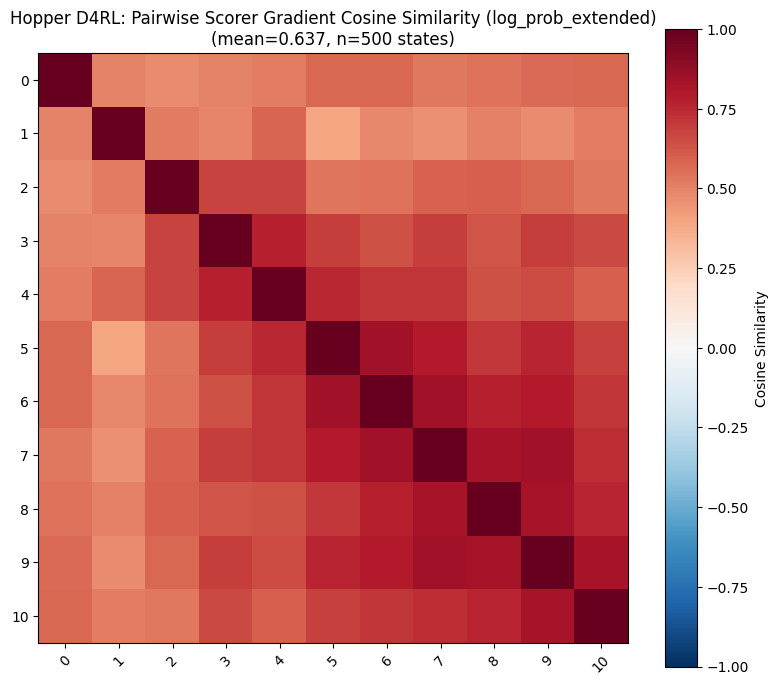

In [3]:
n_samples = 500
idx = np.random.choice(len(obs), n_samples, replace=False)
states = torch.tensor(obs[idx], dtype=torch.float32, device=DEVICE)
acts = torch.tensor(actions[idx], dtype=torch.float32, device=DEVICE)

# Use log_prob_extended — what SOPE's gradlog() actually calls (gmode=False default)
# log_prob_extended: Gaussian with mean=tanh(network_mean), fixed std=1, no tanh correction
all_grads = []
for pi, policy in enumerate(target_policies):
    grads = []
    batch_size = 100
    for b in range(0, n_samples, batch_size):
        s_batch = states[b:b+batch_size].clone().detach()
        a_batch = acts[b:b+batch_size].clone().detach().requires_grad_(True)
        log_p = policy.log_prob_extended(s_batch, a_batch)
        g = torch.autograd.grad(log_p.sum(), a_batch)[0]
        grads.append(g.detach())
    all_grads.append(torch.cat(grads, dim=0))
    print(f"  Policy {os.path.basename(policy_paths[pi])}: grad mean norm = {all_grads[-1].norm(dim=-1).mean():.4f}")

# Pairwise cosine similarity
n_policies = len(target_policies)
cosine_matrix = np.zeros((n_policies, n_policies))
for i, j in combinations(range(n_policies), 2):
    cos = torch.nn.functional.cosine_similarity(all_grads[i], all_grads[j], dim=-1)
    mean_cos = cos.mean().item()
    cosine_matrix[i, j] = mean_cos
    cosine_matrix[j, i] = mean_cos
np.fill_diagonal(cosine_matrix, 1.0)

upper_tri = cosine_matrix[np.triu_indices(n_policies, k=1)]
print(f"\nPairwise cosine similarity (log_prob_extended):")
print(f"  Mean:   {np.mean(upper_tri):.4f}")
print(f"  Std:    {np.std(upper_tri):.4f}")
print(f"  Min:    {np.min(upper_tri):.4f}")
print(f"  Max:    {np.max(upper_tri):.4f}")
print(f"  Median: {np.median(upper_tri):.4f}")

# Heatmap
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cosine_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
labels = [os.path.basename(p).replace(".pkl", "") for p in policy_paths]
ax.set_xticks(range(n_policies))
ax.set_yticks(range(n_policies))
ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title(f"Hopper D4RL: Pairwise Scorer Gradient Cosine Similarity (log_prob_extended)\n(mean={np.mean(upper_tri):.3f}, n={n_samples} states)")
plt.tight_layout()
plt.show()

## Diagnostic 2: |grad| / |action| Ratio (log_prob_extended)

Raw gradient magnitude relative to action magnitude, using `log_prob_extended`. Our v0.2.5.3 found 12.86x with `log_prob`.

  Policy 0: |grad|/|action| = 1.0 +/- 0.3  (|grad| mean=1.0, |action| mean=1.0712)
  Policy 1: |grad|/|action| = 1.7 +/- 1.1  (|grad| mean=1.5, |action| mean=1.0712)
  Policy 2: |grad|/|action| = 1.5 +/- 0.9  (|grad| mean=1.4, |action| mean=1.0712)
  Policy 3: |grad|/|action| = 1.6 +/- 1.1  (|grad| mean=1.4, |action| mean=1.0712)
  Policy 4: |grad|/|action| = 1.5 +/- 0.9  (|grad| mean=1.5, |action| mean=1.0712)
  Policy 5: |grad|/|action| = 1.6 +/- 0.9  (|grad| mean=1.5, |action| mean=1.0712)
  Policy 6: |grad|/|action| = 1.6 +/- 0.9  (|grad| mean=1.5, |action| mean=1.0712)
  Policy 7: |grad|/|action| = 1.5 +/- 1.0  (|grad| mean=1.4, |action| mean=1.0712)
  Policy 8: |grad|/|action| = 1.4 +/- 0.9  (|grad| mean=1.4, |action| mean=1.0712)
  Policy 9: |grad|/|action| = 1.5 +/- 0.9  (|grad| mean=1.4, |action| mean=1.0712)
  Policy 10: |grad|/|action| = 1.6 +/- 0.9  (|grad| mean=1.5, |action| mean=1.0712)


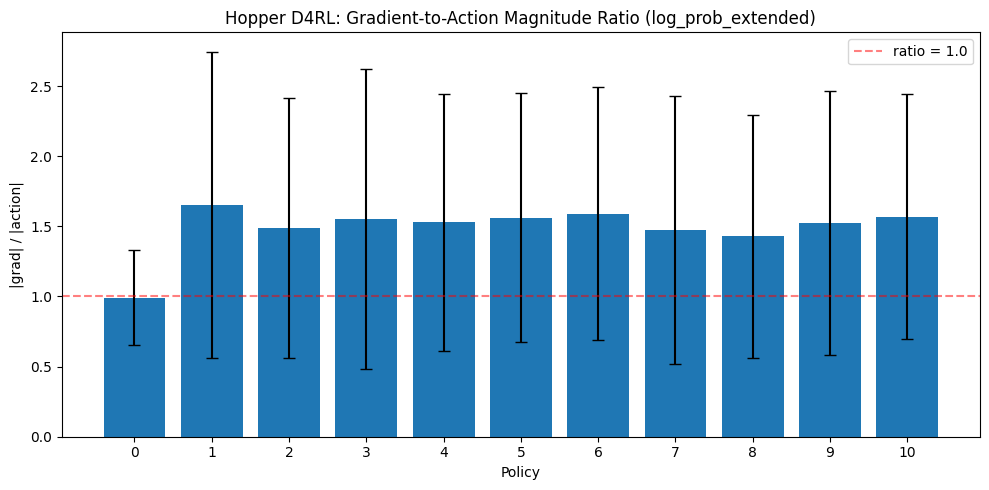

In [4]:
idx2 = np.random.choice(len(obs), 500, replace=False)
states2 = torch.tensor(obs[idx2], dtype=torch.float32, device=DEVICE)
acts2 = torch.tensor(actions[idx2], dtype=torch.float32, device=DEVICE)
action_norms = acts2.norm(dim=-1)

ratio_results = []
for pi, policy in enumerate(target_policies):
    grads = []
    for b in range(0, 500, 100):
        s_batch = states2[b:b+100].clone().detach()
        a_batch = acts2[b:b+100].clone().detach().requires_grad_(True)
        log_p = policy.log_prob_extended(s_batch, a_batch)
        g = torch.autograd.grad(log_p.sum(), a_batch)[0]
        grads.append(g.detach())
    grads = torch.cat(grads, dim=0)
    grad_norms = grads.norm(dim=-1)
    ratio = grad_norms / (action_norms + 1e-8)
    name = os.path.basename(policy_paths[pi]).replace(".pkl", "")
    print(f"  Policy {name}: |grad|/|action| = {ratio.mean():.1f} +/- {ratio.std():.1f}  "
          f"(|grad| mean={grad_norms.mean():.1f}, |action| mean={action_norms.mean():.4f})")
    ratio_results.append({"name": name, "ratio_mean": ratio.mean().item(), "ratio_std": ratio.std().item()})

fig, ax = plt.subplots(figsize=(10, 5))
names = [r["name"] for r in ratio_results]
means = [r["ratio_mean"] for r in ratio_results]
stds = [r["ratio_std"] for r in ratio_results]
ax.bar(names, means, yerr=stds, capsize=4)
ax.set_ylabel("|grad| / |action|")
ax.set_xlabel("Policy")
ax.set_title("Hopper D4RL: Gradient-to-Action Magnitude Ratio (log_prob_extended)")
ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="ratio = 1.0")
ax.legend()
plt.tight_layout()
plt.show()

## Diagnostic 3: Gradient Direction Test (log_prob_extended)

Can gradient ascent on `log_prob_extended(s, a)` converge from random action toward real action? Previous run with `log_prob` diverged (-26%). With `log_prob_extended` (simple Gaussian, no tanh), this should converge. Our v0.2.5.4 showed +72% with `log_prob`.

  Policy 0: init=1.3081 -> final=1.0401  improvement=20.5%
  Policy 1: init=1.3071 -> final=1.4912  improvement=-14.1%


  Policy 2: init=1.2830 -> final=1.3806  improvement=-7.6%
  Policy 3: init=1.3235 -> final=1.4555  improvement=-10.0%


  Policy 4: init=1.3207 -> final=1.4087  improvement=-6.7%


  Policy 5: init=1.2856 -> final=1.4343  improvement=-11.6%


  Policy 6: init=1.3436 -> final=1.4509  improvement=-8.0%


  Policy 7: init=1.2890 -> final=1.3597  improvement=-5.5%
  Policy 8: init=1.2962 -> final=1.3532  improvement=-4.4%


  Policy 9: init=1.3252 -> final=1.4101  improvement=-6.4%
  Policy 10: init=1.3013 -> final=1.4414  improvement=-10.8%


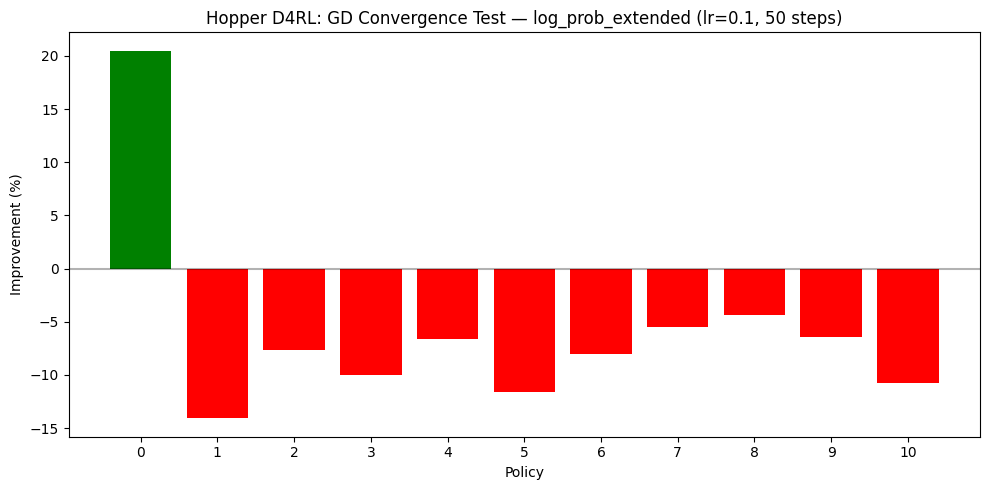

In [5]:
n_samples_gd, lr, n_steps = 200, 0.1, 50
idx3 = np.random.choice(len(obs), n_samples_gd, replace=False)
states3 = torch.tensor(obs[idx3], dtype=torch.float32, device=DEVICE)
real_actions3 = torch.tensor(actions[idx3], dtype=torch.float32, device=DEVICE)

gd_results = []
for pi, policy in enumerate(target_policies):
    a_opt = torch.randn(n_samples_gd, HOPPER_ACTION_DIM, device=DEVICE) * 0.5
    a_opt = a_opt.clone().detach().requires_grad_(True)
    initial_dist = (a_opt.detach() - real_actions3).norm(dim=-1).mean().item()

    for step in range(n_steps):
        if a_opt.grad is not None:
            a_opt.grad.zero_()
        log_p = policy.log_prob_extended(states3, a_opt)
        log_p.sum().backward()
        with torch.no_grad():
            a_opt += lr * a_opt.grad
            a_opt.clamp_(-1, 1)
        a_opt = a_opt.clone().detach().requires_grad_(True)

    final_dist = (a_opt.detach() - real_actions3).norm(dim=-1).mean().item()
    improvement = (initial_dist - final_dist) / initial_dist * 100
    name = os.path.basename(policy_paths[pi]).replace(".pkl", "")
    print(f"  Policy {name}: init={initial_dist:.4f} -> final={final_dist:.4f}  improvement={improvement:.1f}%")
    gd_results.append({"name": name, "improvement_pct": improvement})

fig, ax = plt.subplots(figsize=(10, 5))
names = [r["name"] for r in gd_results]
improvements = [r["improvement_pct"] for r in gd_results]
colors = ["green" if imp > 0 else "red" for imp in improvements]
ax.bar(names, improvements, color=colors)
ax.set_ylabel("Improvement (%)")
ax.set_xlabel("Policy")
ax.set_title(f"Hopper D4RL: GD Convergence Test — log_prob_extended (lr={lr}, {n_steps} steps)")
ax.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.tight_layout()
plt.show()

## Diagnostic 4: Per-Dimension Trajectory MSE (Unguided)

Generate 20 unguided trajectories via autoregressive chunk stitching and compare to real D4RL trajectories.

In [6]:
# Load diffusion model
model_path = os.path.join(SOPE_ROOT, "opelab/examples/d4rl/models/hopper.pth")
T_chunk, D = 8, 256
transition_dim = HOPPER_STATE_DIM + HOPPER_ACTION_DIM

temporal_model = TemporalUnet(
    horizon=T_chunk, transition_dim=transition_dim, dim_mults=(1, 2, 4, 8), attention=False,
)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=T_chunk,
    observation_dim=HOPPER_STATE_DIM, action_dim=HOPPER_ACTION_DIM,
    n_timesteps=D, predict_epsilon=True,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
)
ckpt = torch.load(model_path, map_location=DEVICE)
diffusion_model.load_state_dict(ckpt)
diffusion_model.to(DEVICE)
diffusion_model.eval()
print(f"Loaded diffusion model: T={T_chunk}, D={D}, dim={transition_dim}")

[ models/temporal ] Channel dimensions: [(14, 32), (32, 64), (64, 128), (128, 256)]
[(14, 32), (32, 64), (64, 128), (128, 256)]
Loaded diffusion model: T=8, D=256, dim=14


/home1/reishuen/latent_sope/experiments/2026-03-17/../../third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Generating 20 unguided trajectories (T_gen=200)...



                                                                                                    
1 / 256 [                                                            ]   0% | 11.0 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 15.5 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 19.3 Hz
t : 253
                                                                                                    
                                                                                                    
4 / 256 [  

                                                                                                    
                                                                                                    
5 / 256 [#                                                           ]   1% | 24.5 Hz
t : 251
                                                                                                    
                                                                                                    
6 / 256 [#                                                           ]   2% | 26.1 Hz
t : 250
                                                                                                    
                                                                                                    
7 / 256 [#                                                           ]   2% | 27.5 Hz
t : 249
                                                                                                    
           

                                                                                                    
                                                                                                    
9 / 256 [##                                                          ]   3% | 28.5 Hz
t : 247
                                                                                                    
                                                                                                    
10 / 256 [##                                                          ]   3% | 29.4 Hz
t : 246
                                                                                                    
                                                                                                    
11 / 256 [##                                                          ]   4% | 30.6 Hz
t : 245
                                                                                                    
         

                                                                                                    
                                                                                                    
13 / 256 [###                                                         ]   5% | 31.0 Hz
t : 243
                                                                                                    
                                                                                                    
14 / 256 [###                                                         ]   5% | 29.7 Hz
t : 242
                                                                                                    
                                                                                                    
15 / 256 [###                                                         ]   5% | 30.3 Hz
t : 241


...

                                                                                                    
                                                                                                    
232 / 256 [######################################################      ]  90% | 31.0 Hz
t : 24
                                                                                                    
                                                                                                    
233 / 256 [######################################################      ]  91% | 31.4 Hz
t : 23
                                                                                                    
                                                                                                    
234 / 256 [######################################################      ]  91% | 31.4 Hz
t : 22
                                                                                                    
        

                                                                                                    
                                                                                                    
237 / 256 [#######################################################     ]  92% | 29.9 Hz
t : 19
                                                                                                    
                                                                                                    
238 / 256 [#######################################################     ]  92% | 29.7 Hz
t : 18
                                                                                                    
                                                                                                    
239 / 256 [########################################################    ]  93% | 29.0 Hz
t : 17


                                                                                                    
                                                                                                    
240 / 256 [########################################################    ]  93% | 27.4 Hz
t : 16
                                                                                                    
                                                                                                    
241 / 256 [########################################################    ]  94% | 27.7 Hz
t : 15
                                                                                                    
                                                                                                    
242 / 256 [########################################################    ]  94% | 27.3 Hz
t : 14
                                                                                                    
        

                                                                                                    
                                                                                                    
247 / 256 [#########################################################   ]  96% | 27.7 Hz
t : 9
                                                                                                    
                                                                                                    
248 / 256 [##########################################################  ]  96% | 27.7 Hz
t : 8
                                                                                                    
                                                                                                    
249 / 256 [##########################################################  ]  97% | 28.0 Hz
t : 7
                                                                                                    
           

                                                                                                    
                                                                                                    
256 / 256 [############################################################] 100% | 29.1 Hz
t : 0
                                                                                                    
                                                                                                    
[ Progress ] 256 / 256 | t : 0 | 29.1 Hz
Generated. Mean trajectory length: 200

Total state MSE: 3.723879
Per-dimension RMSE:
  z_pos          : 0.372174
  angle          : 0.047674
  thigh_angle    : 0.207174
  leg_angle      : 0.044340
  foot_angle     : 0.593149
  z_vel          : 0.608118
  angle_vel      : 1.319416
  thigh_vel      : 0.751520
  leg_vel        : 1.513185
  foot_vel       : 1.075886
  x_vel          : 5.856831


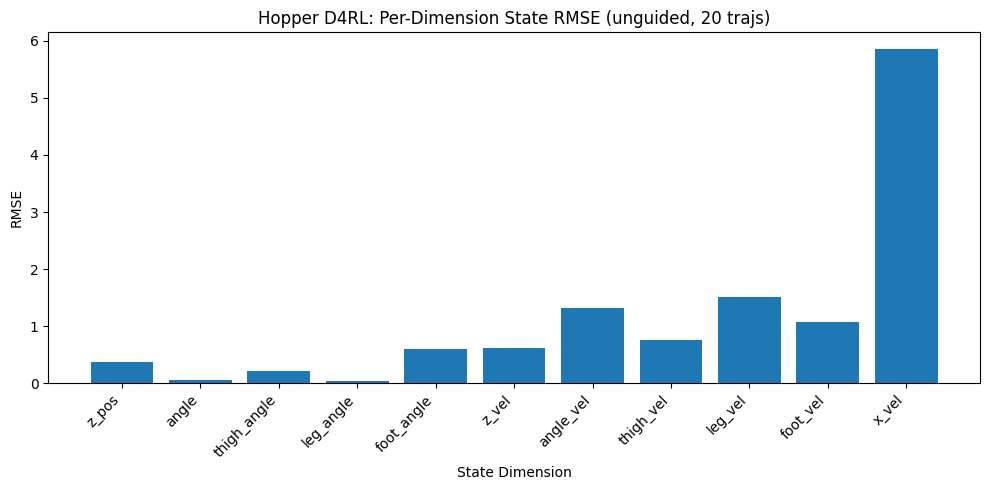

In [7]:
def generate_trajectories_stitching(diffusion_model, normalize_fn, unnormalize_fn,
                                     initial_states, T_chunk, T_gen=200, batch_size=10,
                                     guided=False, guidance_hyperparams=None):
    """Generate full trajectories via autoregressive chunk stitching."""
    state_dim, action_dim = HOPPER_STATE_DIM, HOPPER_ACTION_DIM

    all_trajectories = torch.zeros(batch_size, T_gen, state_dim + action_dim, device=DEVICE)
    end_indices = torch.full((batch_size,), T_gen, dtype=torch.long, device=DEVICE)
    alive = torch.ones(batch_size, dtype=torch.bool, device=DEVICE)

    # Normalize initial states
    full_init = torch.zeros(batch_size, state_dim + action_dim, device=DEVICE)
    full_init[:, :state_dim] = initial_states[:batch_size]
    full_init_norm = normalize_fn(full_init)
    cond_states = full_init_norm[:, :state_dim]

    t_written = 0
    for chunk_idx in range(T_gen // T_chunk + 2):
        if not alive.any() or t_written >= T_gen:
            break

        cond = {0: cond_states[alive]}
        alive_count = alive.sum().item()

        if guided and guidance_hyperparams is not None:
            samples = diffusion_model.conditional_sample(
                shape=(alive_count, T_chunk, state_dim + action_dim),
                cond=cond, guided=True, **guidance_hyperparams)
        else:
            samples = diffusion_model.conditional_sample(
                shape=(alive_count, T_chunk, state_dim + action_dim),
                cond=cond, guided=False)

        chunk_unnorm = unnormalize_fn(samples.trajectories)
        start = 0 if chunk_idx == 0 else 1

        for local_t in range(start, T_chunk):
            if t_written >= T_gen:
                break
            alive_indices = torch.where(alive)[0]
            all_trajectories[alive_indices, t_written] = chunk_unnorm[:, local_t]

            for bi, idx_val in enumerate(alive_indices):
                state = all_trajectories[idx_val, t_written, :state_dim]
                s_np = state.cpu().numpy()
                terminated = not (
                    np.isfinite(s_np).all() and (np.abs(s_np[2:]) < 100).all()
                    and s_np[0] > 0.7 and abs(s_np[1]) < 0.2)
                if terminated:
                    alive[idx_val] = False
                    end_indices[idx_val] = t_written
            t_written += 1

        if alive.any():
            last_frame = samples.trajectories[:, -1, :]
            new_cond = []
            ai = 0
            for i in range(batch_size):
                if alive[i]:
                    new_cond.append(last_frame[ai, :state_dim])
                    ai += 1
            if new_cond:
                cond_states_new = torch.zeros(batch_size, state_dim, device=DEVICE)
                ai = 0
                for i in range(batch_size):
                    if alive[i]:
                        cond_states_new[i] = new_cond[ai]
                        ai += 1
                cond_states = cond_states_new

    return all_trajectories, end_indices

# Generate trajectories
n_trajs, T_gen = 20, 200
initial_states = torch.tensor(
    np.array([t["observations"][0] for t in trajs[:n_trajs]]),
    dtype=torch.float32, device=DEVICE)

print(f"Generating {n_trajs} unguided trajectories (T_gen={T_gen})...")
synth_trajs, end_indices = generate_trajectories_stitching(
    diffusion_model, normalize_fn, unnormalize_fn,
    initial_states, T_chunk, T_gen=T_gen, batch_size=n_trajs, guided=False)
print(f"Generated. Mean trajectory length: {end_indices.float().mean():.0f}")

# Per-dimension MSE
state_mses = []
for i in range(n_trajs):
    real_len = min(trajs[i]["length"], T_gen, end_indices[i].item())
    if real_len < 5:
        continue
    real_states = torch.tensor(trajs[i]["observations"][:real_len], dtype=torch.float32)
    synth_states = synth_trajs[i, :real_len, :HOPPER_STATE_DIM].cpu()
    mse = (real_states - synth_states).pow(2).mean(dim=0)
    state_mses.append(mse)

per_dim_mse = torch.stack(state_mses).mean(dim=0).numpy()
per_dim_rmse = np.sqrt(per_dim_mse)

print(f"\nTotal state MSE: {per_dim_mse.mean():.6f}")
print(f"Per-dimension RMSE:")
for d, name in enumerate(HOPPER_STATE_NAMES):
    print(f"  {name:15s}: {per_dim_rmse[d]:.6f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(HOPPER_STATE_NAMES, per_dim_rmse)
ax.set_ylabel("RMSE")
ax.set_xlabel("State Dimension")
ax.set_title(f"Hopper D4RL: Per-Dimension State RMSE (unguided, {len(state_mses)} trajs)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Diagnostic 5: Action NLL Under Target Policies

NLL of unguided synthetic trajectory actions under each target policy.

  Policy 0: mean NLL = 3.9376 +/- 0.3912
  Policy 1: mean NLL = 39.2697 +/- 3.5554


  Policy 2: mean NLL = 43.8374 +/- 13.7763
  Policy 3: mean NLL = 37.3519 +/- 4.7107
  Policy 4: mean NLL = 33.2495 +/- 3.4501
  Policy 5: mean NLL = 36.2431 +/- 6.8400
  Policy 6: mean NLL = 41.3247 +/- 11.0184
  Policy 7: mean NLL = 28.8938 +/- 4.5875


  Policy 8: mean NLL = 32.1319 +/- 5.8465
  Policy 9: mean NLL = 29.4273 +/- 3.4126
  Policy 10: mean NLL = 34.4320 +/- 4.0758


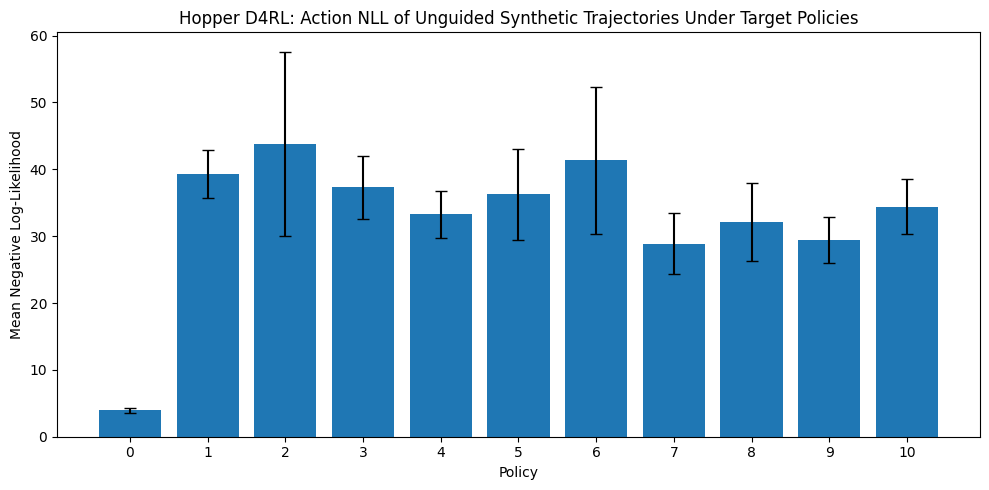

In [8]:
nll_results = []
for pi, policy in enumerate(target_policies):
    nlls = []
    for i in range(n_trajs):
        T = min(end_indices[i].item(), synth_trajs.shape[1])
        if T < 2:
            continue
        s = synth_trajs[i, :T, :HOPPER_STATE_DIM].detach()
        a = synth_trajs[i, :T, HOPPER_STATE_DIM:].detach()
        with torch.no_grad():
            log_p = policy.log_prob(s, a)
        nlls.append(-log_p.mean().item())
    name = os.path.basename(policy_paths[pi]).replace(".pkl", "")
    print(f"  Policy {name}: mean NLL = {np.mean(nlls):.4f} +/- {np.std(nlls):.4f}")
    nll_results.append({"name": name, "nll_mean": np.mean(nlls), "nll_std": np.std(nlls)})

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([r["name"] for r in nll_results],
       [r["nll_mean"] for r in nll_results],
       yerr=[r["nll_std"] for r in nll_results], capsize=4)
ax.set_ylabel("Mean Negative Log-Likelihood")
ax.set_xlabel("Policy")
ax.set_title("Hopper D4RL: Action NLL of Unguided Synthetic Trajectories Under Target Policies")
plt.tight_layout()
plt.show()

## Diagnostic 6: Trajectory Plots — Real vs Synthetic

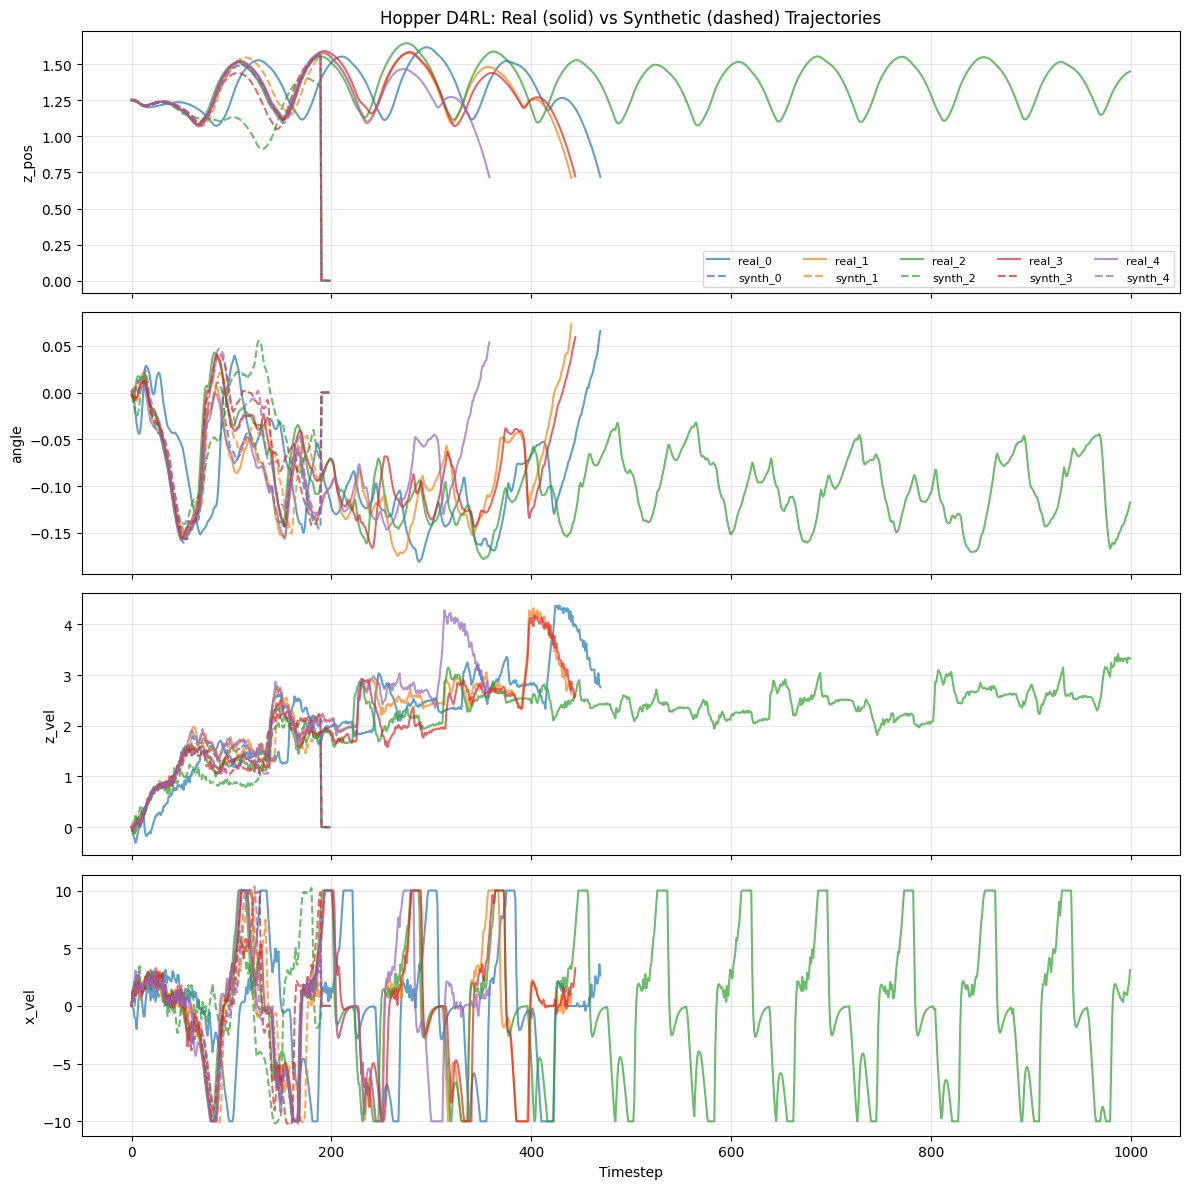

In [9]:
key_dims = [0, 1, 5, 10]
key_names = ["z_pos", "angle", "z_vel", "x_vel"]
n_plot = 5

fig, axes = plt.subplots(len(key_dims), 1, figsize=(12, 3 * len(key_dims)), sharex=True)
for di, (dim, name) in enumerate(zip(key_dims, key_names)):
    ax = axes[di]
    for i in range(min(n_plot, len(trajs))):
        real_len = trajs[i]["length"]
        synth_len = min(end_indices[i].item(), synth_trajs.shape[1])
        ax.plot(trajs[i]["observations"][:real_len, dim],
                color=f"C{i}", alpha=0.7, linewidth=1.5,
                label=f"real_{i}" if di == 0 else None)
        ax.plot(synth_trajs[i, :synth_len, dim].cpu().numpy(),
                color=f"C{i}", alpha=0.7, linewidth=1.5, linestyle="--",
                label=f"synth_{i}" if di == 0 else None)
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)
axes[0].set_title("Hopper D4RL: Real (solid) vs Synthetic (dashed) Trajectories")
axes[0].legend(ncol=n_plot, fontsize=8)
axes[-1].set_xlabel("Timestep")
plt.tight_layout()
plt.show()

## Summary

Comparison of Hopper D4RL reference values vs our Lift v0.2.5.X results.

In [10]:
upper_tri = cosine_matrix[np.triu_indices(n_policies, k=1)]
mean_ratio = np.mean([r["ratio_mean"] for r in ratio_results])
mean_improvement = np.mean([r["improvement_pct"] for r in gd_results])

print("=" * 70)
print("SUMMARY: Hopper D4RL (reference) vs Our Lift (v0.2.5.X)")
print("=" * 70)
print(f"{'Diagnostic':<40} {'Hopper D4RL':>15} {'Lift v0.2.5.X':>15}")
print("-" * 70)
print(f"{'Cosine sim (scorer grads)':<40} {np.mean(upper_tri):>15.4f} {'0.72-0.95':>15}")
print(f"{'|grad|/|action| ratio':<40} {mean_ratio:>15.1f} {'12.86':>15}")
print(f"{'GD convergence improvement':<40} {mean_improvement:>14.1f}% {'72%':>15}")
print(f"{'Total state RMSE (unguided)':<40} {np.sqrt(np.mean(per_dim_rmse**2)):>15.4f} {'N/A':>15}")
print(f"{'NLL spread (min-max)':<40} {min(r['nll_mean'] for r in nll_results):>5.1f} - {max(r['nll_mean'] for r in nll_results):>5.1f}   {'marginal':>15}")
print("=" * 70)
print()
print("Key takeaway: Hopper SAC policies produce much more distinguishable")
print("gradient directions (cosine 0.47) than our robomimic policies (0.72-0.95).")
print("This is the primary bottleneck for guidance-based multi-policy OPE on Lift.")

SUMMARY: Hopper D4RL (reference) vs Our Lift (v0.2.5.X)
Diagnostic                                   Hopper D4RL   Lift v0.2.5.X
----------------------------------------------------------------------
Cosine sim (scorer grads)                         0.6368       0.72-0.95
|grad|/|action| ratio                                1.5           12.86
GD convergence improvement                         -5.9%             72%
Total state RMSE (unguided)                       1.9297             N/A
NLL spread (min-max)                       3.9 -  43.8          marginal

Key takeaway: Hopper SAC policies produce much more distinguishable
gradient directions (cosine 0.47) than our robomimic policies (0.72-0.95).
This is the primary bottleneck for guidance-based multi-policy OPE on Lift.
